# Question 9

This question delves into the more fundamental aspects of gradient descent. The gradient is essentially the derivative of the function with repsect to it's values, or a partial derivative. From this partialized derivative, a global minium can be seen for both values of the functions inputs.

The gradient descent with respect to f_1(x,y) and f_2(x,y) are essentially their partial derivatives respect to x and y. 

For f_1(x,y):
partial derivative with respect to x: 2(x-2)
partial derivative with respect to y: 2(y-3)

gradient for f_1(x,y) would therefore be expressed as: 
delt_f_1(x,y) = [2(x-2), 2(y-3)]

The same forllows for f_2(x,y)
partial derivative with respect to x: 40((x+3)-(y-3)^2)
partial derivative with respect to y: -2+2(y-3)-80(y-3)((x+3)-(y-3)^2)

gradient for f_2(x,y) would therefor be expressed as:
delt_f_2(x,y) = [40((x+3)-(y-3)^2), -2+2(y-3)-80(y-3)((x+3)-(y-3)^2)]

Following the logic for back propigation were essentially:
w_i(k+1) = w_i(k) - eta*delt_w
where delt_w = eta* partial deriviate of e with respect to wi

This can be mirrored with these particiualr functions for updating x and y values corresponding to a global minimum for the gradients:


x value update:
x(k+1) = x(k) - h * partial derivative with respect to x
y(k+1) = y(k) - h * partial deriviatve with respect to y 

In [105]:
# imports 

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd


In [106]:
# the functions f_1(x,y) and f_2(x,y) are two dimensional. Therefore, a meshgrid
# needs to be applied. as such, Z is plotted for f_1 an f_2 where Z = f(x,y)

# Initialize mesgrid for plotting and setting x and y values:

x_val = np.linspace(-15, 15, 100)
y_val = np.linspace(-15, 15, 100)
x, y = np.meshgrid(x_val, y_val)

# Plot the original functions f_1(x,y) and f_2(x,y) as z_1 and z_2
z_1 = ((x-2)**2)  + ((y-3)**2)
z_2 = (1-(y-3))**2 + 20*((x+3)-(y-3)**2)**2


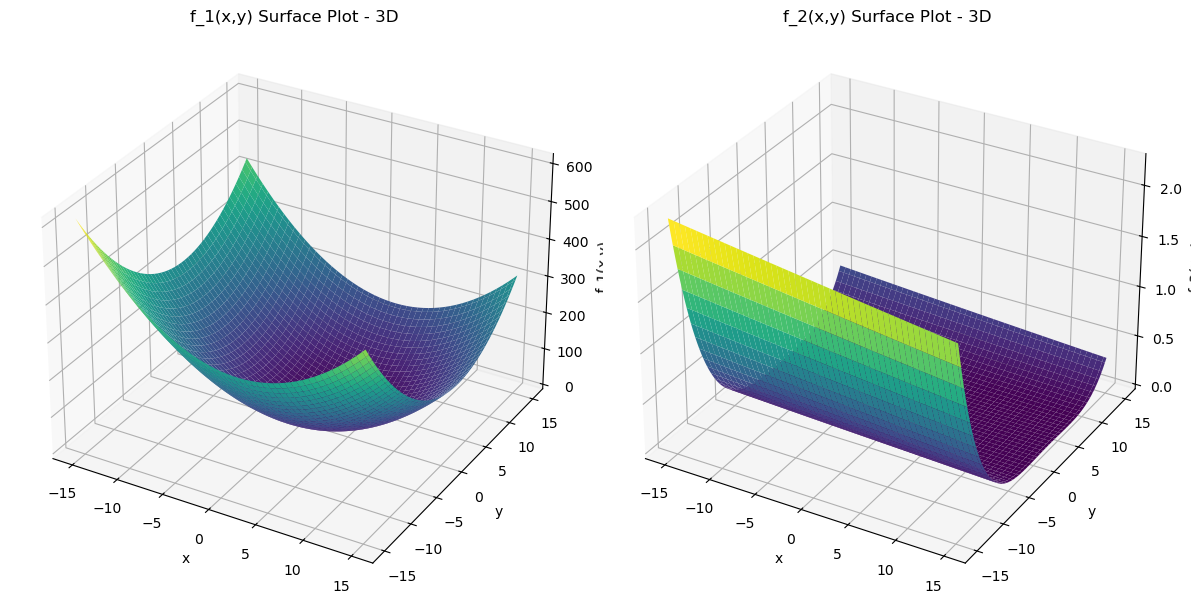

In [107]:
# z_1 and z_2 can be plotted with 3d surfaces

# 3d plots
fig = plt.figure(figsize=(12,6))

#f_1 plot
ax_1 = fig.add_subplot(121, projection = '3d')
ax_1.plot_surface(x, y, z_1, cmap = 'viridis')
ax_1.set_title('f_1(x,y) Surface Plot - 3D')
ax_1.set_xlabel('x')
ax_1.set_ylabel('y')
ax_1.set_zlabel('f_1(x,y)')

#f_2 plot
ax_2 = fig.add_subplot(122, projection='3d')
ax_2.plot_surface(x, y, z_2, cmap='viridis')
ax_2.set_title('f_2(x,y) Surface Plot - 3D')
ax_2.set_xlabel('x')
ax_2.set_ylabel('y')
ax_2.set_zlabel('f_2(x,y)')

plt.tight_layout()
plt.show()

For gradient descent, rather than update weights as with a dataset, the goal is to update the input x and values that will lead to a global minium.

Applying gradient descent to f_1(x,y)

In [108]:
# applying gradient descent to find global mininum for x and y values for f_1(x,y)

# initialize x and y
x1 = 0;
y1 = 0; 

# set learning rate eta
eta = 0.5;

# set iteration number for T
T = 100;

# initialize arrays
f_1_x_update = [];
f_1_y_update = [];

# initialize update function f_1(x,y) array to plot global minimum
f_1_val_update = [];

for i in range(100):

    # Graidents for partial derivatves:

    # partial deriviate of f_1 with respect to x
    grad_x = 2*(x1-2)
  
    # partial derivative of f_1 with respect to y
    grad_y = 2*(y1-3)

    # updating x and y:
    x1 = x1 - eta*grad_x
    y1 = y1 - eta*grad_y

    # record x and y as arrays
    f_1_x_update.append(x1)
    f_1_y_update.append(y1)
    f_1_val_update.append((x1 - 2)**2 + (y1-3)**2)

# display updated x and y values as a table

xy_update_f_1 = pd.DataFrame({
    'Iteration - T': range(1, T + 1),
    'x': f_1_x_update,
    'y': f_1_y_update,
    'f1_value': f_1_val_update
})

print("Gradient Descent for f1(x,y) with eta = 0.5")
print(xy_update_f_1)



Gradient Descent for f1(x,y) with eta = 0.5
    Iteration - T    x    y  f1_value
0               1  2.0  3.0       0.0
1               2  2.0  3.0       0.0
2               3  2.0  3.0       0.0
3               4  2.0  3.0       0.0
4               5  2.0  3.0       0.0
..            ...  ...  ...       ...
95             96  2.0  3.0       0.0
96             97  2.0  3.0       0.0
97             98  2.0  3.0       0.0
98             99  2.0  3.0       0.0
99            100  2.0  3.0       0.0

[100 rows x 4 columns]


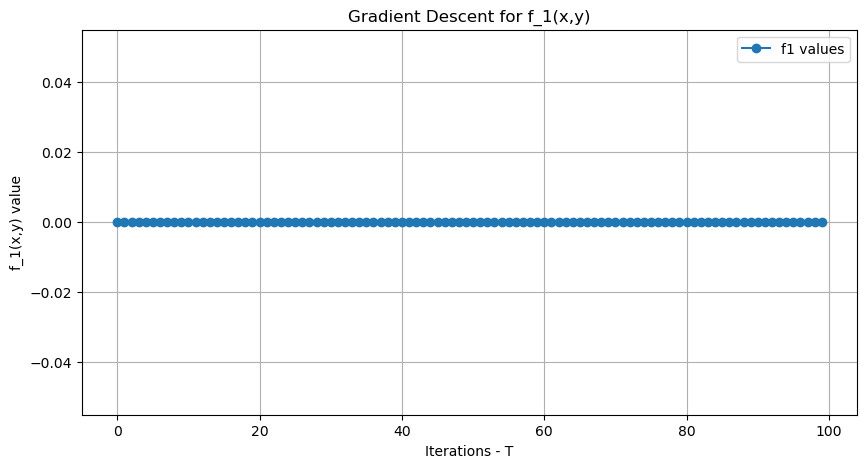

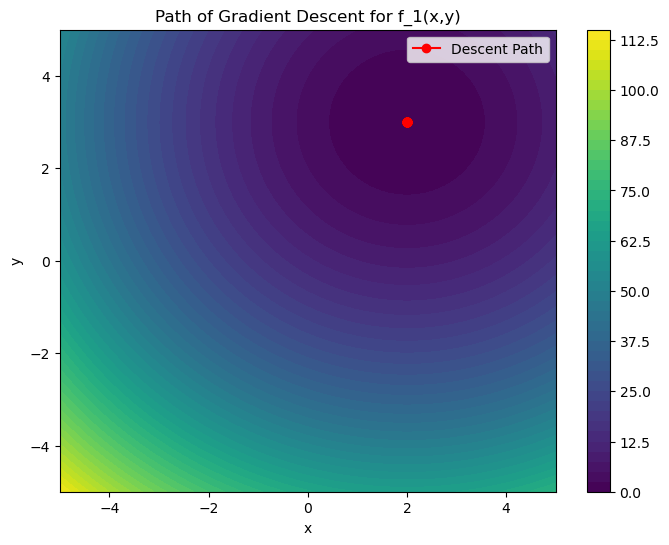

In [109]:
# Vizualiing graident descent: The gradietn descent canb e easier visaulized by plotting 
# the values of f_1(x,y) as x and y are going towards a global mininum. countour plots
# can also be used to plot the descent path of (x,y) as they go toward a global mininum

# plotting value of f_1(x,y) over iterations: 

plt.figure(figsize = (10, 5))
plt.plot(
    range(len(f_1_val_update)),
    f_1_val_update,
    marker = 'o',
    label = 'f1 values'
)
plt.title('Gradient Descent for f_1(x,y)')
plt.xlabel('Iterations - T')
plt.ylabel('f_1(x,y) value')
plt.grid(True)
plt.legend()
plt.show

# contour plot for gradient descent path for f_1(x,y)
x1_vals = np.linspace(-5, 5, 100)
y1_vals = np.linspace(-5, 5, 100)
X1, Y1 = np.meshgrid(x1_vals, y1_vals)
Z1 = (X1-2)**2 + (Y1-3)**2

plt.figure(figsize=(8, 6))
contour1 = plt.contourf(X1, Y1, Z1, levels=50, cmap='viridis')
plt.colorbar(contour1)
plt.plot(f_1_x_update, f_1_y_update, 'r-o', label='Descent Path')
plt.title('Path of Gradient Descent for f_1(x,y)')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.show()



Applying gradient descent to f_2(x,y)

In [110]:
# initialize x and y
x2 = 0
y2 = 0

# set learning rate eta (note: a smaller eta value must be used)
eta2 = 0.001

# set iteration number for T
T2 = 100

# initiazlie arrays to store values for x, y, and function value
f_2_x_update = []
f_2_y_update = []
f_2_val_update = []

for i in range(T2):
    # Gradients for partial derivatives of f_2:
    grad_x2 = 40 * ((x2 + 3) - (y2 - 3)**2)
    grad_y2 = -2 + 2*(y2-3) - 80*(y2-3)*((x2+3)-(y2-3)**2)
    
    # updating x and y
    x2 = x2 - eta2 * grad_x2
    y2 = y2 - eta2 * grad_y2
    
    # record the updated x and y
    f_2_x_update.append(x2)
    f_2_y_update.append(y2)
    
    # this line calculates and records the function's value
    f_2_val_update.append((1-(y2-3))**2 + 20*((x2+3)-(y2-3)**2)**2)

print("Gradient Descent for f2(x,y) with eta = 0.001")
print(pd.DataFrame({
    'Iteration - T': range(1, T2 + 1), 
    'x': f_2_x_update, 
    'y': f_2_y_update, 
    'f2_value': f_2_val_update
    }))

Gradient Descent for f2(x,y) with eta = 0.001
    Iteration - T         x         y   f2_value
0               1  0.240000  1.448000  20.333765
1               2  0.206748  1.349890  11.705997
2               3  0.187393  1.291313   8.771133
3               4  0.176681  1.260126   7.954036
4               5  0.170701  1.244794   7.752990
..            ...       ...       ...        ...
95             96  0.034503  1.268497   7.487608
96             97  0.033047  1.268918   7.485311
97             98  0.031591  1.269339   7.483013
98             99  0.030135  1.269760   7.480716
99            100  0.028678  1.270182   7.478417

[100 rows x 4 columns]


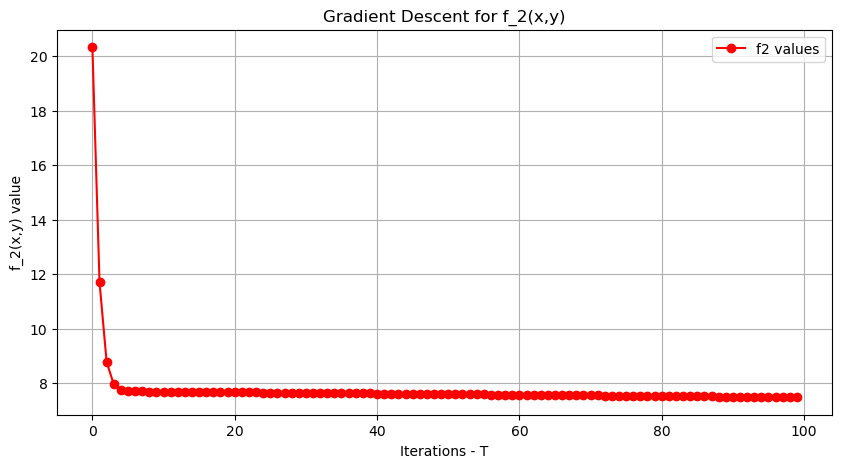

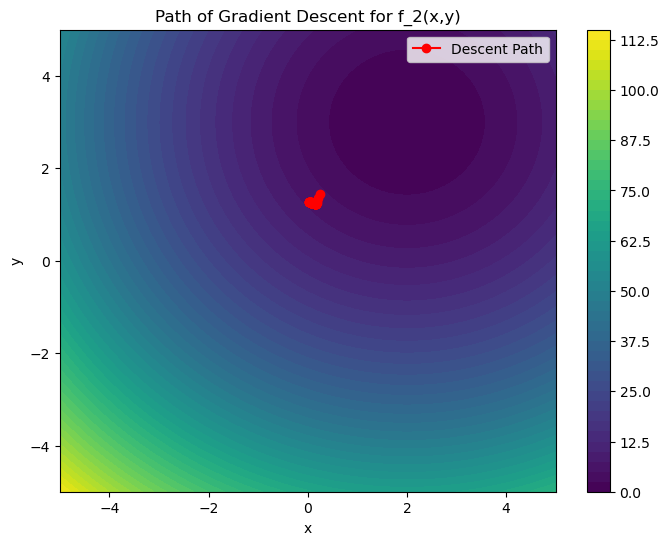

In [111]:
# Visualizing Gradient descent for f_2(x,y)

# plotting value of f_1(x,y) over iterations: 

plt.figure(figsize = (10, 5))
plt.plot(
    range(len(f_2_val_update)),
    f_2_val_update,
    marker = 'o',
    color = 'red',
    label = 'f2 values'
)
plt.title('Gradient Descent for f_2(x,y)')
plt.xlabel('Iterations - T')
plt.ylabel('f_2(x,y) value')
plt.grid(True)
plt.legend()
plt.show

# contour plot for gradient descent path
x2_vals = np.linspace(-5, 5, 100)
y2_vals = np.linspace(-5, 5, 100)
X2, Y2 = np.meshgrid(x2_vals, y2_vals)
Z2 = (X2-2)**2 + (Y2-3)**2

plt.figure(figsize=(8, 6))
contour2 = plt.contourf(X2, Y2, Z2, levels=50, cmap='viridis')
plt.colorbar(contour2)
plt.plot(f_2_x_update, f_2_y_update, 'r-o', label='Descent Path')
plt.title('Path of Gradient Descent for f_2(x,y)')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.show()

For both f_1(x,y) and f_2(x,y) the values graident descent and values can seem rather too blunt. There's no smooth gradiation, especially when observed for f_1(x,y) with eta = 0.5. As such, adjustments to eta can be made.

code is reapplied with changed eta values

f_1(x,y); eta = 0.1

Gradient Descent for f1(x,y) with eta = 0.1
    Iteration - T        x        y      f1_value
0               1  0.40000  0.60000  8.320000e+00
1               2  0.72000  1.08000  5.324800e+00
2               3  0.97600  1.46400  3.407872e+00
3               4  1.18080  1.77120  2.181038e+00
4               5  1.34464  2.01696  1.395864e+00
..            ...      ...      ...           ...
95             96  2.00000  3.00000  3.215297e-18
96             97  2.00000  3.00000  2.057789e-18
97             98  2.00000  3.00000  1.316985e-18
98             99  2.00000  3.00000  8.428705e-19
99            100  2.00000  3.00000  5.394370e-19

[100 rows x 4 columns]


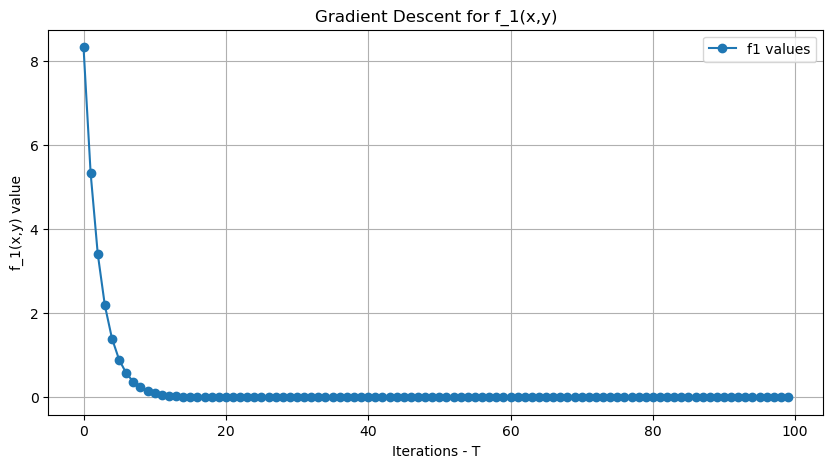

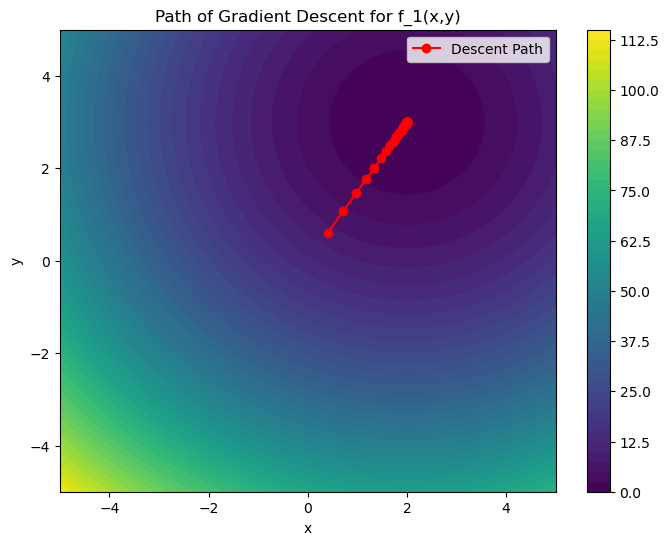

In [112]:
# applying gradient descent to find global mininum for x and y values for f_1(x,y)

# initialize x and y
x1 = 0;
y1 = 0; 

# set learning rate eta
eta = 0.1;

# set iteration number for T
T = 100;

# initialize arrays
f_1_x_update = [];
f_1_y_update = [];

# initialize update function f_1(x,y) array to plot global minimum
f_1_val_update = [];

for i in range(100):

    # Graidents for partial derivatves:

    # partial deriviate of f_1 with respect to x
    grad_x = 2*(x1-2)
  
    # partial derivative of f_1 with respect to y
    grad_y = 2*(y1-3)

    # updating x and y:
    x1 = x1 - eta*grad_x
    y1 = y1 - eta*grad_y

    # record x and y as arrays
    f_1_x_update.append(x1)
    f_1_y_update.append(y1)
    f_1_val_update.append((x1 - 2)**2 + (y1-3)**2)

# display updated x and y values as a table

xy_update_f_1 = pd.DataFrame({
    'Iteration - T': range(1, T + 1),
    'x': f_1_x_update,
    'y': f_1_y_update,
    'f1_value': f_1_val_update
})

print("Gradient Descent for f1(x,y) with eta = 0.1")
print(xy_update_f_1)

# plotting value of f_1(x,y) over iterations: 

plt.figure(figsize = (10, 5))
plt.plot(
    range(len(f_1_val_update)),
    f_1_val_update,
    marker = 'o',
    label = 'f1 values'
)
plt.title('Gradient Descent for f_1(x,y)')
plt.xlabel('Iterations - T')
plt.ylabel('f_1(x,y) value')
plt.grid(True)
plt.legend()
plt.show

# contour plot for gradient descent path for f_1(x,y)
x1_vals = np.linspace(-5, 5, 100)
y1_vals = np.linspace(-5, 5, 100)
X1, Y1 = np.meshgrid(x1_vals, y1_vals)
Z1 = (X1-2)**2 + (Y1-3)**2

plt.figure(figsize=(8, 6))
contour1 = plt.contourf(X1, Y1, Z1, levels=50, cmap='viridis')
plt.colorbar(contour1)
plt.plot(f_1_x_update, f_1_y_update, 'r-o', label='Descent Path')
plt.title('Path of Gradient Descent for f_1(x,y)')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.show()

f_2(x,y); eta = 0.00001

Gradient Descent for f2(x,y) with eta = 0.00001
    Iteration - T         x         y    f2_value
0               1  0.002400  0.014480  714.666161
1               2  0.004764  0.028677  694.149341
2               3  0.007094  0.042601  674.409982
3               4  0.009390  0.056258  655.410857
4               5  0.011652  0.069658  637.116911
..            ...       ...       ...         ...
95             96  0.135871  0.720933   95.482202
96             97  0.136694  0.724751   93.964296
97             98  0.137511  0.728530   92.477414
98             99  0.138319  0.732270   91.020798
99            100  0.139121  0.735972   89.593714

[100 rows x 4 columns]


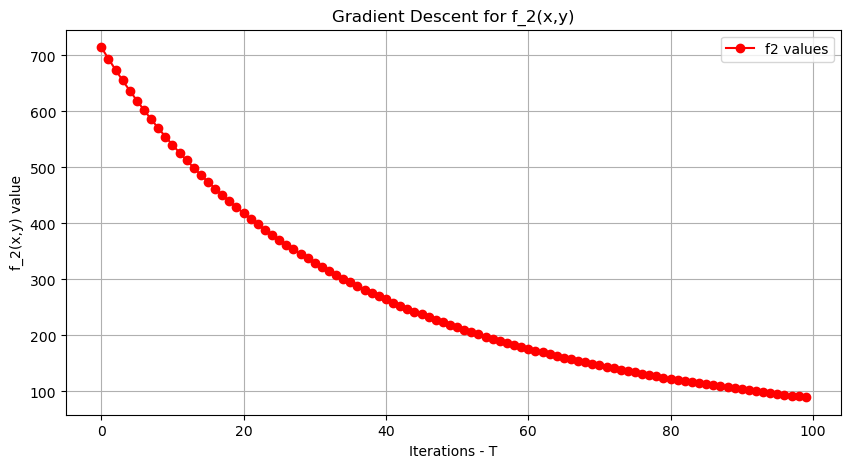

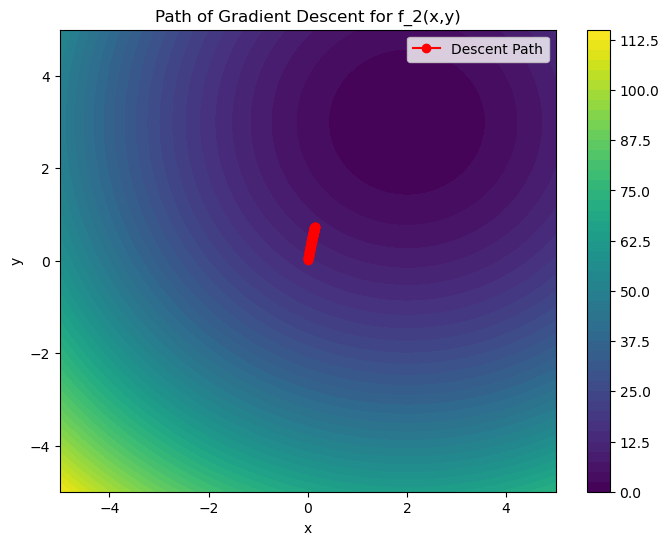

In [113]:
# initialize x and y
x2 = 0
y2 = 0

# set learning rate eta (note: a smaller eta value must be used)
eta2 = 0.00001

# set iteration number for T
T2 = 100

# initiazlie arrays to store values for x, y, and function value
f_2_x_update = []
f_2_y_update = []
f_2_val_update = []

for i in range(T2):
    # Gradients for partial derivatives of f_2:
    grad_x2 = 40 * ((x2 + 3) - (y2 - 3)**2)
    grad_y2 = -2 + 2*(y2-3) - 80*(y2-3)*((x2+3)-(y2-3)**2)
    
    # updating x and y
    x2 = x2 - eta2 * grad_x2
    y2 = y2 - eta2 * grad_y2
    
    # record the updated x and y
    f_2_x_update.append(x2)
    f_2_y_update.append(y2)
    
    # this line calculates and records the function's value
    f_2_val_update.append((1-(y2-3))**2 + 20*((x2+3)-(y2-3)**2)**2)

print("Gradient Descent for f2(x,y) with eta = 0.00001")
print(pd.DataFrame({
    'Iteration - T': range(1, T2 + 1), 
    'x': f_2_x_update, 
    'y': f_2_y_update, 
    'f2_value': f_2_val_update
    }))

# Visualizing Gradient descent for f_2(x,y)

# plotting value of f_1(x,y) over iterations: 

plt.figure(figsize = (10, 5))
plt.plot(
    range(len(f_2_val_update)),
    f_2_val_update,
    marker = 'o',
    color = 'red',
    label = 'f2 values'
)
plt.title('Gradient Descent for f_2(x,y)')
plt.xlabel('Iterations - T')
plt.ylabel('f_2(x,y) value')
plt.grid(True)
plt.legend()
plt.show

# contour plot for gradient descent path
x2_vals = np.linspace(-5, 5, 100)
y2_vals = np.linspace(-5, 5, 100)
X2, Y2 = np.meshgrid(x2_vals, y2_vals)
Z2 = (X2-2)**2 + (Y2-3)**2

plt.figure(figsize=(8, 6))
contour2 = plt.contourf(X2, Y2, Z2, levels=50, cmap='viridis')
plt.colorbar(contour2)
plt.plot(f_2_x_update, f_2_y_update, 'r-o', label='Descent Path')
plt.title('Path of Gradient Descent for f_2(x,y)')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.show()

One more attempt at using different eta values, with eta = 0.005 for f_1(x,y) and eta = 0.00005 for f_2(x,y)

f_1(x,y); eta = 0.005

Gradient Descent for f1(x,y) with eta = 0.005
    Iteration - T         x         y   f1_value
0               1  0.020000  0.030000  12.741300
1               2  0.039800  0.059700  12.487748
2               3  0.059402  0.089103  12.239242
3               4  0.078808  0.118212  11.995681
4               5  0.098020  0.147030  11.756967
..            ...       ...       ...        ...
95             96  1.237906  1.856859   1.887560
96             97  1.245527  1.868290   1.849997
97             98  1.253071  1.879607   1.813182
98             99  1.260541  1.890811   1.777100
99            100  1.267935  1.901903   1.741736

[100 rows x 4 columns]


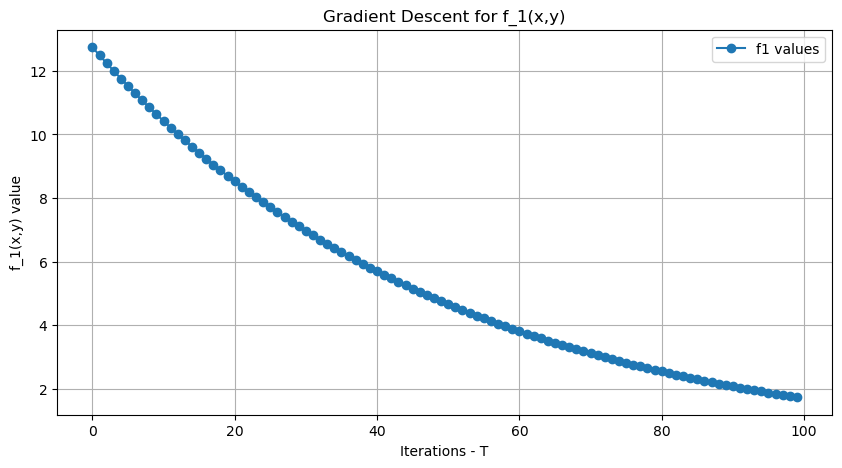

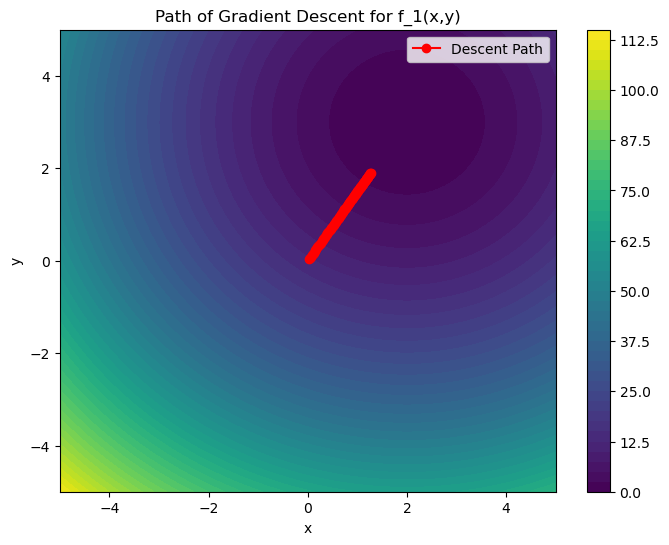

In [114]:
# applying gradient descent to find global mininum for x and y values for f_1(x,y)

# initialize x and y
x1 = 0;
y1 = 0; 

# set learning rate eta
eta = 0.005;

# set iteration number for T
T = 100;

# initialize arrays
f_1_x_update = [];
f_1_y_update = [];

# initialize update function f_1(x,y) array to plot global minimum
f_1_val_update = [];

for i in range(100):

    # Graidents for partial derivatves:

    # partial deriviate of f_1 with respect to x
    grad_x = 2*(x1-2)
  
    # partial derivative of f_1 with respect to y
    grad_y = 2*(y1-3)

    # updating x and y:
    x1 = x1 - eta*grad_x
    y1 = y1 - eta*grad_y

    # record x and y as arrays
    f_1_x_update.append(x1)
    f_1_y_update.append(y1)
    f_1_val_update.append((x1 - 2)**2 + (y1-3)**2)

# display updated x and y values as a table

xy_update_f_1 = pd.DataFrame({
    'Iteration - T': range(1, T + 1),
    'x': f_1_x_update,
    'y': f_1_y_update,
    'f1_value': f_1_val_update
})

print("Gradient Descent for f1(x,y) with eta = 0.005")
print(xy_update_f_1)

# plotting value of f_1(x,y) over iterations: 

plt.figure(figsize = (10, 5))
plt.plot(
    range(len(f_1_val_update)),
    f_1_val_update,
    marker = 'o',
    label = 'f1 values'
)
plt.title('Gradient Descent for f_1(x,y)')
plt.xlabel('Iterations - T')
plt.ylabel('f_1(x,y) value')
plt.grid(True)
plt.legend()
plt.show

# contour plot for gradient descent path for f_1(x,y)
x1_vals = np.linspace(-5, 5, 100)
y1_vals = np.linspace(-5, 5, 100)
X1, Y1 = np.meshgrid(x1_vals, y1_vals)
Z1 = (X1-2)**2 + (Y1-3)**2

plt.figure(figsize=(8, 6))
contour1 = plt.contourf(X1, Y1, Z1, levels=50, cmap='viridis')
plt.colorbar(contour1)
plt.plot(f_1_x_update, f_1_y_update, 'r-o', label='Descent Path')
plt.title('Path of Gradient Descent for f_1(x,y)')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.show()

f_2(x,y); eta = 0.00005

Gradient Descent for f2(x,y) with eta = 0.00005
    Iteration - T         x         y    f2_value
0               1  0.012000  0.072400  633.440476
1               2  0.023118  0.137889  549.196476
2               3  0.033455  0.197447  479.270778
3               4  0.043097  0.251870  420.691912
4               5  0.052115  0.301812  371.214186
..            ...       ...       ...         ...
95             96  0.237893  1.167169    8.319581
96             97  0.238136  1.168342    8.291298
97             98  0.238370  1.169481    8.264647
98             99  0.238595  1.170587    8.239531
99            100  0.238811  1.171662    8.215859

[100 rows x 4 columns]


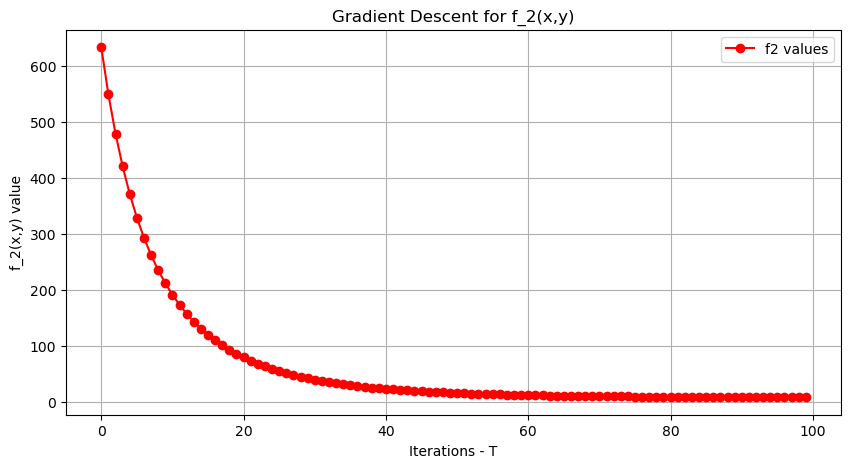

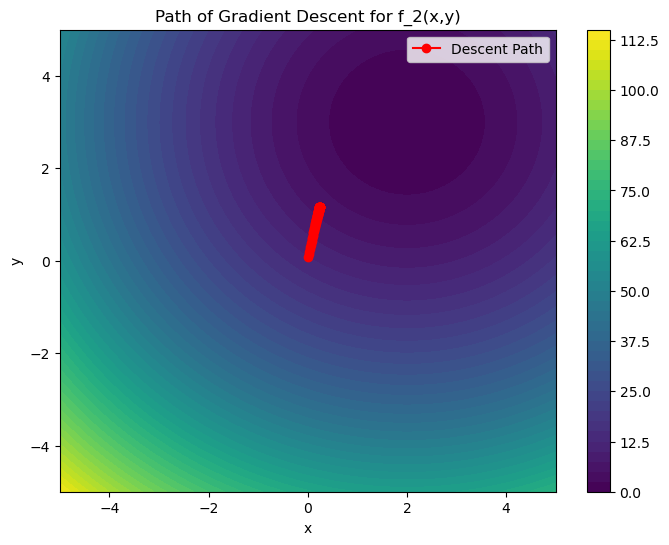

In [115]:
# initialize x and y
x2 = 0
y2 = 0

# set learning rate eta (note: a smaller eta value must be used)
eta2 = 0.00005

# set iteration number for T
T2 = 100

# initiazlie arrays to store values for x, y, and function value
f_2_x_update = []
f_2_y_update = []
f_2_val_update = []

for i in range(T2):
    # Gradients for partial derivatives of f_2:
    grad_x2 = 40 * ((x2 + 3) - (y2 - 3)**2)
    grad_y2 = -2 + 2*(y2-3) - 80*(y2-3)*((x2+3)-(y2-3)**2)
    
    # updating x and y
    x2 = x2 - eta2 * grad_x2
    y2 = y2 - eta2 * grad_y2
    
    # record the updated x and y
    f_2_x_update.append(x2)
    f_2_y_update.append(y2)
    
    # this line calculates and records the function's value
    f_2_val_update.append((1-(y2-3))**2 + 20*((x2+3)-(y2-3)**2)**2)

print("Gradient Descent for f2(x,y) with eta = 0.00005")
print(pd.DataFrame({
    'Iteration - T': range(1, T2 + 1), 
    'x': f_2_x_update, 
    'y': f_2_y_update, 
    'f2_value': f_2_val_update
    }))

# Visualizing Gradient descent for f_2(x,y)

# plotting value of f_1(x,y) over iterations: 

plt.figure(figsize = (10, 5))
plt.plot(
    range(len(f_2_val_update)),
    f_2_val_update,
    marker = 'o',
    color = 'red',
    label = 'f2 values'
)
plt.title('Gradient Descent for f_2(x,y)')
plt.xlabel('Iterations - T')
plt.ylabel('f_2(x,y) value')
plt.grid(True)
plt.legend()
plt.show

# contour plot for gradient descent path
x2_vals = np.linspace(-5, 5, 100)
y2_vals = np.linspace(-5, 5, 100)
X2, Y2 = np.meshgrid(x2_vals, y2_vals)
Z2 = (X2-2)**2 + (Y2-3)**2

plt.figure(figsize=(8, 6))
contour2 = plt.contourf(X2, Y2, Z2, levels=50, cmap='viridis')
plt.colorbar(contour2)
plt.plot(f_2_x_update, f_2_y_update, 'r-o', label='Descent Path')
plt.title('Path of Gradient Descent for f_2(x,y)')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.show()

From the previous exploration so far, it's appears that the mininum values for both f_1(x,y) and f_2(x,y) lie somewhere close to zero, as expceted for a global minium. More values can be explored but for the sake of brevity,  it appears that an eta value of 0.1 for f_1(x,y) and eta of 0.00005 appears to result in decent minimal values for the gradient. 

Gradient descent when applied to descending a function's partial derivative to find the optimal output for a function (via  a global mininum) is akin to going down a step hill. There may be several paths, some over rocky terrain, some over softer, but there exists a path that makes going down th hill more easire. That particular path is altered based on the direction of the steps taken to go down the hill along with determing how steep parts of the hill are. for both funcitons, f(x,y) can be though of as the position on the hill - the goal is to reach from the top to the bottom. As such, x and y can be though of the directions to step. Each step is adjusted based on the previous footing of the other step, i.e., the partial derivatives of the funciton with respect to x an dy. 

It should therefore follow from this hill example taht as gradient descent learning leads to a better path down the hill, adjusting the learning factor for functions f_1(x,y) and f_2(x,y). Rather go through a series of infinite values for x and y, the most best performing values can be found (or at least estimated) via gradient descent. similar to the hill analogy, the learning coefficient eta is vital as it sets the 'intensity' of the learning. the higher the eta value is, the more intense gradient descent, similar to over stepping or running when going down the hill. this can cause overshoots in reaching a global mininum. In turn, a too small of an eta value will result in a slower descent that may take even more iterations to go through, like stepping too slowly and too little when going down the hill resulting in a longer time going down. likewsise, a small eta value can be too computationally expesnive. As such, trade-offs need to be ackonwledged to reach a compromise as to an appropriate eta value.